This notebook is to pick the s_lo and s_hi for the solver. We pick the s_lo and s_hi based on tick_b/normalized_vega (has units of s); how far total implied vol moves for per one-tick change in the quote. Consider the reference value of SPX~1600, $0.05 tick and D~1. 

In [ ]:
from optionslib.vol.implied import normalized_price, normalized_vega
import numpy as np
import matplotlib.pyplot as plt
import math

TICK_DOLLARS = 0.05
F_REF = 1600.0
D_REF = 1.0
TICK_B = TICK_DOLLARS / (D_REF * math.sqrt(F_REF * F_REF))

1. Upper bound values : 
    - s = 5 -> 0.0018 (0.18 vol points moving at T = 1)
    - s = 6 -> 0.007
    - s = 8 -> 0.23
    - s = 10 -> 21
    So s_hi= 5 is selected as vega decays like exp(-s^2/8), so b saturates against its ceiling.
2. Upper bound is moneyness-independent because at high s, x^2/2s^2 is negligible compared to s^2/8. Small variation could be attributed to change of tick_b with strike.

In [ ]:
for x in [0.0, 0.2, 0.3, 0.5, -0.3, -0.5]:
    K = F_REF / math.exp(x)  # since x = ln(F/K)
    tick_b = TICK_DOLLARS / (D_REF * math.sqrt(F_REF * K))
    print(f"--- x = {x} ---")
    for s in [2, 3, 4, 5, 6, 8, 10]:
        print(s, tick_b / normalized_vega(x, 1, s))

--- x = 0.0 ---
2 0.00012914785481632789
3 0.00024127995767164815
4 0.0005788005293879438
5 0.0017828311427834208
6 0.0070512339537206
8 0.23350479924393458
10 21.01943217284325
--- x = 0.2 ---
2 0.00014344589264917357
3 0.0002672488192130428
4 0.0006404736042901266
5 0.0019719100280232546
6 0.0077971492487412305
8 0.25814337055544356
10 23.23471162955262
--- x = 0.3 ---
2 0.00015174597555951986
3 0.0002817324634304076
4 0.0006743642595675823
5 0.002075086065983595
6 0.008202611920199904
8 0.2714846921839662
10 24.43208802734828
--- x = 0.5 ---
2 0.00017109310968319952
3 0.00031414252942182474
4 0.0007490235383463826
5 0.0023006751662589604
6 0.00908545563125256
8 0.30041226723916375
10 27.023243105041296
--- x = -0.3 ---
2 0.00011241618360961493
3 0.00020871254226679167
4 0.0004995813308642004
5 0.0015372615671633927
6 0.006076644367665142
8 0.2011208066060497
10 18.099735979959252
--- x = -0.5 ---
2 0.00010377321668843695
3 0.0001905370756140147
4 0.0004543057408535223
5 0.0013954300

  
3. Lower bound has moneyness dependence. The exponent (x^2)/(2s^2) dominates in this region, giving wedge at boundary |x|/s ~ 2.5-3. Since scalar bound can not express a ratio constraint, s_lo is not fixed. Any value of fixed s_lo is too loose for the wings and too tight for ATM.

In [ ]:
for x in [0.0, 0.2, 0.3, 0.5, -0.3, -0.5]:
    K = F_REF / math.exp(x)  # since x = ln(F/K)
    tick_b = TICK_DOLLARS / (D_REF * math.sqrt(F_REF * K))
    print(f"--- x = {x} ---")
    for s in [0.05, 0.1, 0.2, 0.5, 1.0]:
        print(s, tick_b / normalized_vega(x, 1, s))

--- x = 0.0 ---
0.05 7.835661619917287e-05
0.1 7.84301099716826e-05
0.2 7.872477503576102e-05
0.5 8.081866241879328e-05
1.0 8.876193599411518e-05
--- x = 0.2 ---
0.05 0.25814337055544356
0.1 0.0006404736042901266
0.2 0.00014344589264917357
0.5 9.675750591205943e-05
1.0 0.00010007880337345493
--- x = 0.3 ---
0.05 5977.512864133763
0.1 0.008202611920199897
0.2 0.0002817324634304075
0.5 0.00011241618360961495
1.0 0.00010787335599574647
--- x = 0.5 ---
0.05 5.2164300555406106e+17
0.1 27.023243105041246
0.2 0.002300675166258959
0.5 0.00017109310968319952
1.0 0.0001291478548163279
--- x = -0.3 ---
0.05 4428.2504441096535
0.1 0.006076644367665136
0.2 0.00020871254226679164
0.5 8.327995711750424e-05
1.0 7.991454764773442e-05
--- x = -0.5 ---
0.05 3.1639247629318554e+17
0.1 16.390425468075538
0.2 0.0013954300263755188
0.5 0.00010377321668843695
1.0 7.833213358221875e-05


4. s_lo = 0.05 chosen, where the arithmetic failes, rather than where the answer stops being useful. The informativeness filter will live in data layer as a condition, |x|/s, applied after inversion using the returned s.  
5. Originally s_hi was close to 15.8 but the measurement indicates inversion is meaningless after 5. Old limit was based on market assumption and that is why this exercise was necessary to make an informed decision on s_hi rather than working off of an assumption.

In the figure below; x axis is log-moneyness, s is total volatility, and color is log10 of sensitivity; how far implied s moves per tick of quote noise. Lower (darker) is better. Since dead zone reached 10^290 the scale is clipped. The white contours are the precision target of roughly 0.1 vol points at T =1. Inside this region inversion is precise enough; outside, it is not. Sensitivity is the best near x~0 and s~1.2. Then it degrades in every direction. The low-s boundary notched at x=0 represents the wedge and this is the reason fixed s_lo does not work across moneyness. Tick_b scales with exp(x/2), so same vega buys less precision at high strikes. This fact is represented by tilt on the upper contour. The vega is moneyness independent at large s, but normalization depends on moneyness. Red dashed line shows the upper bound selected for this project sits above the upper contour.

/tmp/ipykernel_28325/2535229406.py:8: RuntimeWarning: divide by zero encountered in divide
  sens = tick_b / vega


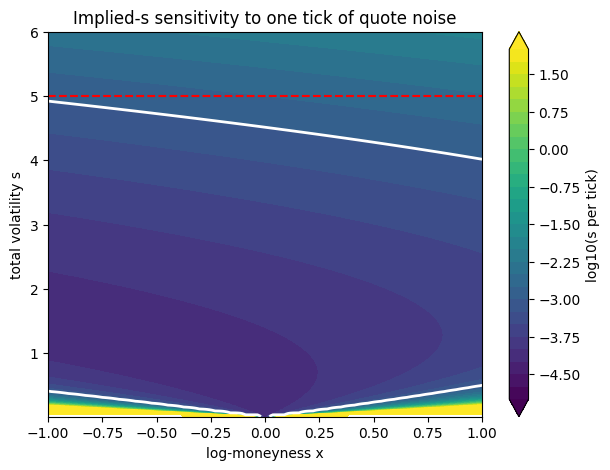

In [ ]:
x_grid = np.linspace(-1.0, 1.0, 200)
s_grid = np.linspace(0.01, 6.0, 200)
X, S = np.meshgrid(x_grid, s_grid)

K = F_REF / np.exp(X)
tick_b = TICK_DOLLARS / (D_REF * np.sqrt(F_REF * K))
vega = np.exp(-(X**2) / (2 * S**2) - S**2 / 8) / np.sqrt(2 * np.pi)
sens = tick_b / vega

fig, ax = plt.subplots(figsize=(7, 5))

cf = ax.contourf(X, S, np.log10(sens), levels=np.linspace(-5, 2, 29), extend="both")
fig.colorbar(cf, ax=ax, label="log10(s per tick)")

ax.contour(X, S, sens, levels=[1e-3], colors="white", linewidths=2)
ax.axhline(5.0, color="red", linestyle="--")

ax.set_xlabel("log-moneyness x")
ax.set_ylabel("total volatility s")
ax.set_title("Implied-s sensitivity to one tick of quote noise")

plt.show()